<a href="https://colab.research.google.com/github/ysnigdha/Licence-Plate-Detection-using-YOLOv8/blob/main/Automated_License_Plate_Detection_%26_Blurring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Data Loading**

In [30]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fareselmenshawii/large-license-plate-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'large-license-plate-dataset' dataset.
Path to dataset files: /kaggle/input/large-license-plate-dataset


In [31]:
%cd /root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1

/root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1


In [32]:
!ls

blurred_output	blurred_outputs_test  images  labels


In [33]:
!ls images

test  train  val


In [34]:
!ls labels

test  train  train.cache  val  val.cache


In [56]:
!pip install ultralytics opencv-python matplotlib seaborn pillow numpy pandas torch torchvision albumentations tensorboard scikit-learn

In [36]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from pathlib import Path
import glob
import json
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [37]:
def explore_dataset(base_path):
    """Explore the dataset structure and show sample statistics"""
    print("Dataset Structure:")
    print("-" * 50)

    for split in ['train', 'test', 'val']:
        img_path = os.path.join(base_path, 'images', split)
        label_path = os.path.join(base_path, 'labels', split)

        if os.path.exists(img_path):
            img_count = len(os.listdir(img_path))
            print(f"{split.upper()} - Images: {img_count}")

        if os.path.exists(label_path):
            label_count = len(os.listdir(label_path))
            print(f"{split.upper()} - Labels: {label_count}")
        print()

In [38]:
PATH="/root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1"
explore_dataset(PATH)

Dataset Structure:
--------------------------------------------------
TRAIN - Images: 25470
TRAIN - Labels: 25470

TEST - Images: 386
TEST - Labels: 386

VAL - Images: 1073
VAL - Labels: 1073



Data Visualisation

In [39]:
def visualize_sample_data(images_path, labels_path, num_samples=10):
    """Visualize sample images with their bounding boxes"""
    image_files = glob.glob(os.path.join(images_path, "*.jpg")) + \
                  glob.glob(os.path.join(images_path, "*.png"))

    plt.figure(figsize=(15, 5 * num_samples))

    for i in range(min(num_samples, len(image_files))):
        img_file = image_files[i]
        img_name = os.path.basename(img_file)
        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_file = os.path.join(labels_path, label_name)

        # Load image
        img = cv2.imread(img_file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Load labels if exists
        if os.path.exists(label_file):
            with open(label_file, 'r') as f:
                labels = f.readlines()

            # Draw bounding boxes
            for label in labels:
                parts = label.strip().split()
                if len(parts) >= 5:
                    class_id, x_center, y_center, width, height = map(float, parts[:5])

                    # Convert YOLO format to pixel coordinates
                    x1 = int((x_center - width/2) * w)
                    y1 = int((y_center - height/2) * h)
                    x2 = int((x_center + width/2) * w)
                    y2 = int((y_center + height/2) * h)

                    # Draw rectangle
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, f'License Plate', (x1, y1-10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

        plt.subplot(num_samples, 1, i+1)
        plt.imshow(img)
        plt.title(f'Sample {i+1}: {img_name}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


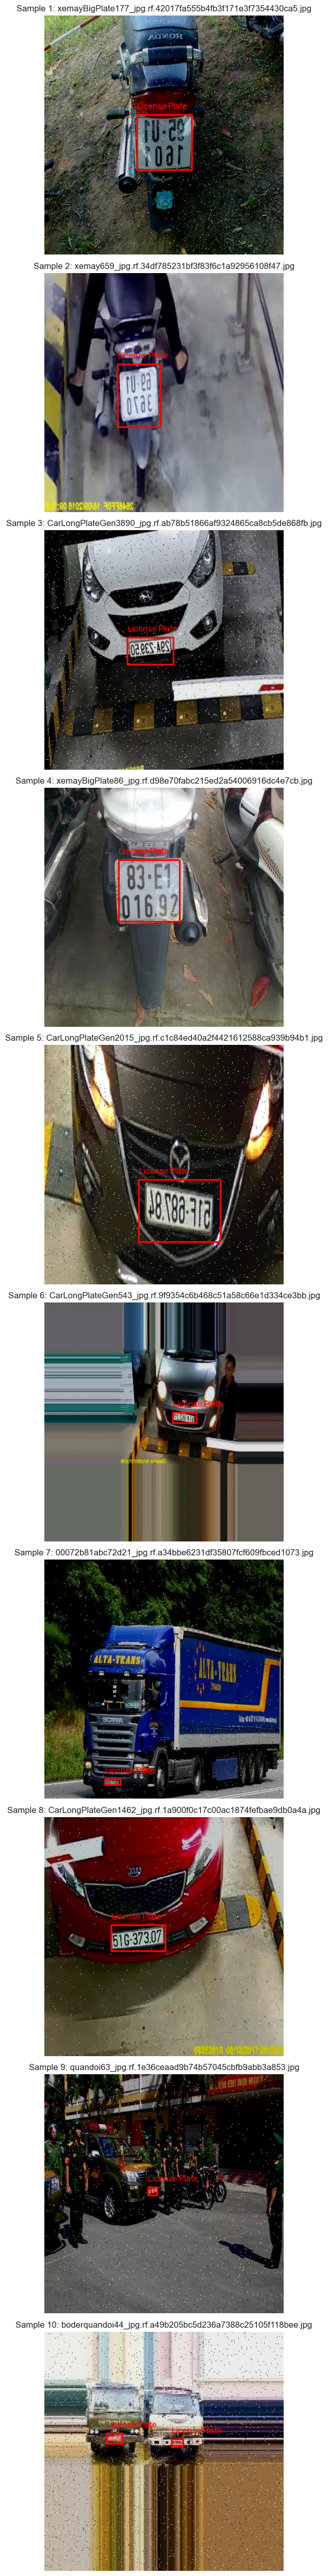

In [40]:
visualize_sample_data(os.path.join(PATH, 'images/train'), os.path.join(PATH, 'labels/train'))

In [41]:
def create_dataset_yaml(base_path, yaml_path='/content/dataset.yaml'):
    yaml_content = f"""
    path: "{base_path}"
    train: images/train
    val: images/val
    test: images/test
    nc: 1
    names: ['license_plate']
    """

    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

    print(f"Dataset YAML created: {yaml_path}")
    return yaml_path


YOLOv8 model downloading

In [42]:
!wget -P /content https://github.com/ultralytics/assets/releases/download/v8.3.0/yolov8n.pt

--2026-09-21 00:05:24--  https://github.com/ultralytics/assets/releases/download/v8.3.0/yolov8n.pt
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/101dd207-c6a9-4ee0-bfeb-34e12d2b8f40?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-21T00%3A44%3A25Z&rscd=attachment%3B+filename%3Dyolov8n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-20T23%3A43%3A29Z&ske=2026-09-21T00%3A44%3A25Z&sks=b&skv=2018-11-09&sig=Oo7cn3%2B1bTX%2BGXNi%2FmMgvCYwyU%2BSY7bQMX5Qc%2B27neE%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4OTk0OTQyNSwibmJmIjoxNzg5OTQ5MTI1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9

In [43]:
!ls /content

dataset.yaml		 sample_data	yolov8n.pt
license_plate_detection  small_dataset	yolov8n.pt.1


In [44]:
def train_yolo_model(yaml_path, epochs=100, img_size=640, batch_size=16):
    """Train YOLO model for license plate detection"""
    print("Starting YOLO training...")
    print("-" * 50)

    # Initialize YOLO model (using YOLOv8n for faster training)
    model = YOLO('/content/yolov8n.pt')  # make sure weights are here

    # Train the model
    results = model.train(
        data=yaml_path,
        epochs=epochs,
        imgsz=img_size,
        batch=batch_size,
        device='cpu',  # Use CPU since GPU is not available
        project='/content/license_plate_detection',  # save to writable path
        name='train',
        save_period=10,  # Save checkpoint every 10 epochs
    )

    return model, results

In [45]:
def detect_license_plates(model, image_path, conf_threshold=0.5):
    """Detect license plates in an image using trained YOLO model"""
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image {image_path}")
        return None, []

    # Run detection
    results = model(img, conf=conf_threshold)

    detections = []
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                # Get bounding box coordinates
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                confidence = box.conf[0].cpu().numpy()

                detections.append({
                    'bbox': (int(x1), int(y1), int(x2), int(y2)),
                    'confidence': float(confidence)
                })

    return img, detections

def blur_license_plates(img, detections, blur_intensity=51):
    """Apply Gaussian blur to detected license plate regions"""
    blurred_img = img.copy()

    for detection in detections:
        x1, y1, x2, y2 = detection['bbox']

        # Extract the license plate region
        plate_region = blurred_img[y1:y2, x1:x2]

        # Apply Gaussian blur
        blurred_region = cv2.GaussianBlur(plate_region, (blur_intensity, blur_intensity), 0)

        # Replace the original region with blurred version
        blurred_img[y1:y2, x1:x2] = blurred_region

    return blurred_img

In [46]:
def process_single_image(model, image_path, output_path=None, conf_threshold=0.5, blur_intensity=51, visualize=True):
    """Process a single image: detect and blur license plates"""
    print(f"Processing: {image_path}")

    # Detect license plates
    img, detections = detect_license_plates(model, image_path, conf_threshold)

    if img is None:
        return None

    print(f"Found {len(detections)} license plate(s)")

    # Blur license plates
    blurred_img = blur_license_plates(img, detections, blur_intensity)

    # Save output if path provided
    if output_path:
        cv2.imwrite(output_path, blurred_img)
        print(f"Saved blurred image: {output_path}")

    # Visualize results
    if visualize:
        plt.figure(figsize=(15, 5))

        # Original with detections
        plt.subplot(1, 2, 1)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        for detection in detections:
            x1, y1, x2, y2 = detection['bbox']
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3)
            cv2.putText(img_rgb, f"Conf: {detection['confidence']:.2f}",
                       (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        plt.imshow(img_rgb)
        plt.title('Original with Detections')
        plt.axis('off')

        # Blurred result
        plt.subplot(1, 2, 2)
        blurred_rgb = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2RGB)
        plt.imshow(blurred_rgb)
        plt.title('Blurred License Plates')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    return blurred_img

In [47]:
def process_batch_images(model, input_folder, output_folder, conf_threshold=0.5, blur_intensity=51):
    """Process multiple images in a folder"""
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)

    # Get all image files
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp']
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(input_folder, ext)))
        image_files.extend(glob.glob(os.path.join(input_folder, ext.upper())))

    print(f"Found {len(image_files)} images to process")

    processed_count = 0
    total_detections = 0

    for img_file in image_files:
        img_name = os.path.basename(img_file)
        output_path = os.path.join(output_folder, f"blurred_{img_name}")

        # Process image
        img, detections = detect_license_plates(model, img_file, conf_threshold)

        if img is not None:
            total_detections += len(detections)
            blurred_img = blur_license_plates(img, detections, blur_intensity)
            cv2.imwrite(output_path, blurred_img)
            processed_count += 1

            if processed_count % 10 == 0:
                print(f"Processed {processed_count} images...")

    print(f"Batch processing complete!")
    print(f"Processed {processed_count} images")
    print(f"Total license plates detected: {total_detections}")


In [48]:
def evaluate_model(model, test_images_path, test_labels_path):
    """Evaluate model performance on test set"""
    image_files = glob.glob(os.path.join(test_images_path, "*.jpg")) + \
                  glob.glob(os.path.join(test_images_path, "*.png"))

    total_images = len(image_files)
    total_detections = 0
    total_ground_truth = 0

    print(f"Evaluating on {total_images} test images...")

    for img_file in image_files:
        img_name = os.path.basename(img_file)
        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_file = os.path.join(test_labels_path, label_name)

        # Count ground truth
        if os.path.exists(label_file):
            with open(label_file, 'r') as f:
                total_ground_truth += len(f.readlines())

        # Count detections
        _, detections = detect_license_plates(model, img_file)
        if detections:
            total_detections += len(detections)

    print(f"Ground truth license plates: {total_ground_truth}")
    print(f"Model detections: {total_detections}")
    print(f"Average detections per image: {total_detections/total_images:.2f}")

In [49]:
def main_pipeline(base_path, train_model=True, process_images=True):
    """Main execution pipeline for the license plate blurring system"""
    print("=== STREET VIEW LICENSE PLATE BLURRING SYSTEM ===")
    print("=" * 60)

    # Step 1: Explore dataset
    print("\n1. EXPLORING DATASET")
    print("-" * 30)
    explore_dataset(base_path)

    # Visualize sample data from training set
    train_images = os.path.join(base_path, 'images', 'train')
    train_labels = os.path.join(base_path, 'labels', 'train')
    if os.path.exists(train_images) and os.path.exists(train_labels):
        print("Sample training data:")
        visualize_sample_data(train_images, train_labels, num_samples=2)

    # Step 2: Create dataset configuration
    print("\n2. CREATING DATASET CONFIGURATION")
    print("-" * 40)
    yaml_path = create_dataset_yaml(base_path)

    # Step 3: Train model (if requested)
    model = None
    if train_model:
        print("\n3. TRAINING YOLO MODEL")
        print("-" * 30)
        model, results = train_yolo_model(yaml_path, epochs=10, img_size=640, batch_size=8)
        print("Training completed!")
    else:
        print("\n3. LOADING PRE-TRAINED MODEL")
        print("-" * 35)
        # Load existing model (you would specify the path to your trained model)
        try:
          model = YOLO('/content/license_plate_detection/train/weights/best.pt')
          print("Pre-trained model loaded successfully!")
        except:
          print("No pre-trained model found. Using default YOLOv8n...")
          model = YOLO('/content/yolov8n.pt')


    # Step 4: Test on sample images
    if process_images and model:
        print("\n4. TESTING LICENSE PLATE DETECTION AND BLURRING")
        print("-" * 55)

        # Test on validation images
        val_images = os.path.join(base_path, 'images', 'val')
        if os.path.exists(val_images):
            test_images = glob.glob(os.path.join(val_images, "*.jpg")) + \
                         glob.glob(os.path.join(val_images, "*.png"))

            if test_images:
                print("Processing sample validation images...")
                for i, img_path in enumerate(test_images[:3]):  # Process first 3 images
                    print(f"\nProcessing sample {i+1}:")
                    process_single_image(model, img_path, conf_threshold=0.3, visualize=True)

        # Step 5: Batch processing example
        print("\n5. BATCH PROCESSING EXAMPLE")
        print("-" * 35)
        output_folder = "blurred_output"
        process_batch_images(model, val_images, output_folder, conf_threshold=0.3)

    print("\n=== PIPELINE COMPLETED ===")
    return model


In [50]:
import os, glob, shutil

#  Change this number to control how many training samples you want
MAX_TRAIN_IMAGES = 1000

def create_subset_dataset(base_path, subset_size=MAX_TRAIN_IMAGES, subset_path="/content/small_dataset"):
    os.makedirs(os.path.join(subset_path, "images/train"), exist_ok=True)
    os.makedirs(os.path.join(subset_path, "labels/train"), exist_ok=True)
    os.makedirs(os.path.join(subset_path, "images/val"), exist_ok=True)
    os.makedirs(os.path.join(subset_path, "labels/val"), exist_ok=True)

    # pick first N train images
    train_images = glob.glob(os.path.join(base_path, "images/train", "*.jpg"))
    train_images = train_images[:subset_size]

    for img_path in train_images:
        fname = os.path.basename(img_path)
        lbl_path = os.path.join(base_path, "labels/train", fname.replace(".jpg", ".txt"))

        shutil.copy(img_path, os.path.join(subset_path, "images/train", fname))
        if os.path.exists(lbl_path):
            shutil.copy(lbl_path, os.path.join(subset_path, "labels/train", fname.replace(".jpg", ".txt")))

    # copy val set fully (or limit if needed)
    val_images = glob.glob(os.path.join(base_path, "images/val", "*.jpg"))
    for img_path in val_images:
        fname = os.path.basename(img_path)
        lbl_path = os.path.join(base_path, "labels/val", fname.replace(".jpg", ".txt"))

        shutil.copy(img_path, os.path.join(subset_path, "images/val", fname))
        if os.path.exists(lbl_path):
            shutil.copy(lbl_path, os.path.join(subset_path, "labels/val", fname.replace(".jpg", ".txt")))

    print(f"Created subset dataset with {len(train_images)} train images at {subset_path}")
    return subset_path


model Training

Created subset dataset with 1000 train images at /content/small_dataset
=== STREET VIEW LICENSE PLATE BLURRING SYSTEM ===

1. EXPLORING DATASET
------------------------------
Dataset Structure:
--------------------------------------------------
TRAIN - Images: 1000
TRAIN - Labels: 1000


VAL - Images: 1073
VAL - Labels: 1073

Sample training data:


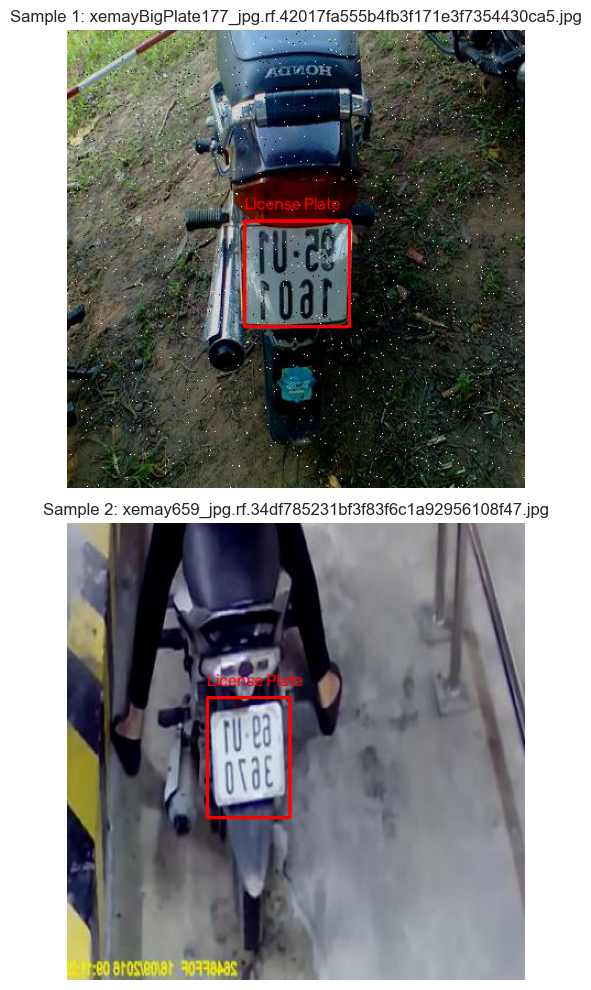


2. CREATING DATASET CONFIGURATION
----------------------------------------
Dataset YAML created: /content/dataset.yaml

3. TRAINING YOLO MODEL
------------------------------
Starting YOLO training...
--------------------------------------------------
Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

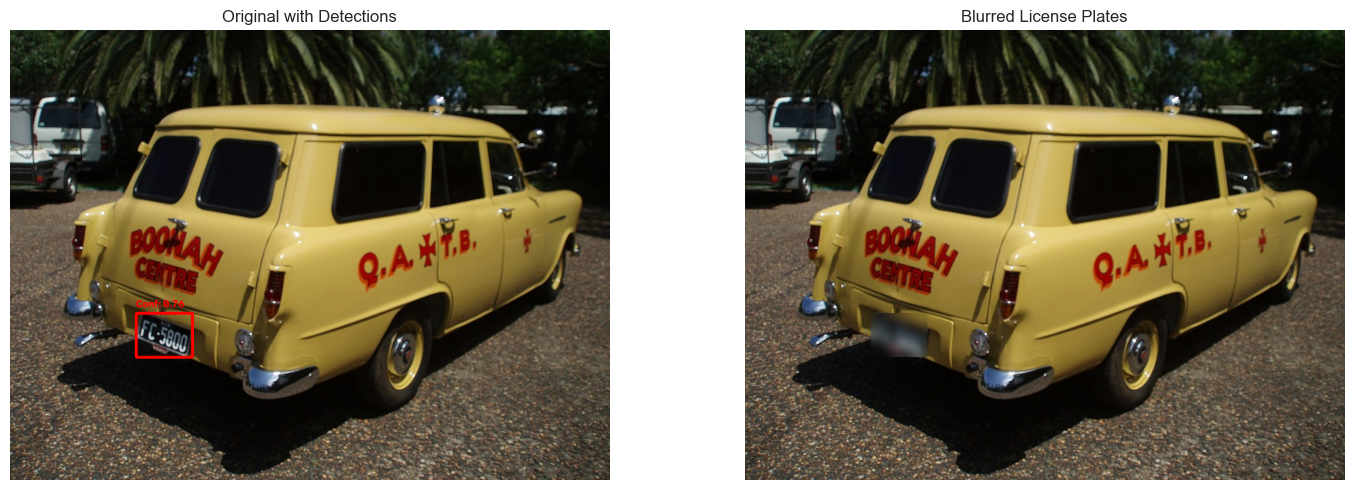


Processing sample 2:
Processing: /content/small_dataset/images/val/d9fcf87185551855.jpg

0: 480x640 3 license_plates, 179.3ms
Speed: 7.3ms preprocess, 179.3ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
Found 3 license plate(s)


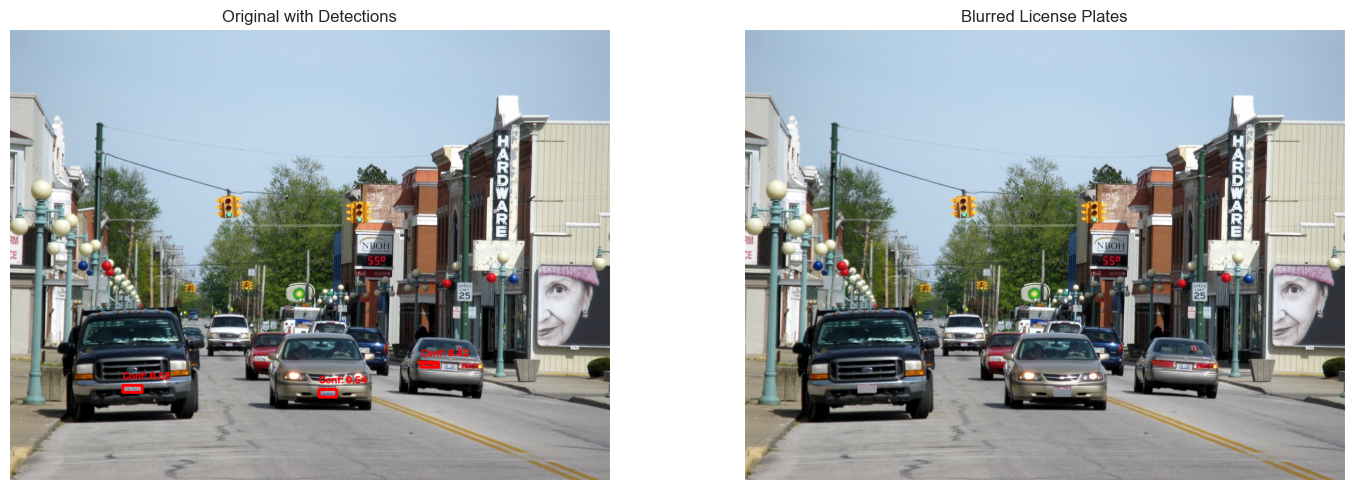


Processing sample 3:
Processing: /content/small_dataset/images/val/65e0c1ac77e02ead.jpg

0: 480x640 1 license_plate, 192.6ms
Speed: 6.8ms preprocess, 192.6ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Found 1 license plate(s)


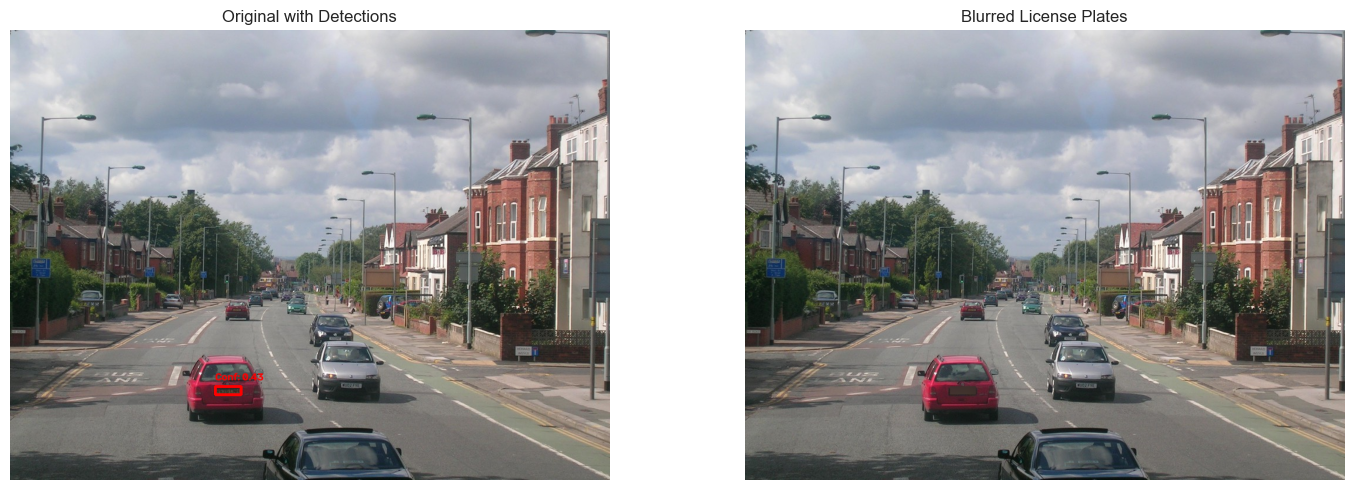


5. BATCH PROCESSING EXAMPLE
-----------------------------------
Found 1073 images to process

0: 480x640 1 license_plate, 170.5ms
Speed: 9.7ms preprocess, 170.5ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 license_plates, 166.7ms
Speed: 9.0ms preprocess, 166.7ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 license_plate, 191.8ms
Speed: 8.3ms preprocess, 191.8ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 448x640 2 license_plates, 189.1ms
Speed: 6.5ms preprocess, 189.1ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)

0: 480x640 2 license_plates, 181.4ms
Speed: 8.9ms preprocess, 181.4ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 320x640 1 license_plate, 145.7ms
Speed: 6.5ms preprocess, 145.7ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 640)

0: 512x640 1 license_plate, 201.8ms
Speed: 8.0ms preprocess, 201.8ms inference, 0.9ms postpr

In [51]:
#  Change this variable to control training subset size
MAX_TRAIN_IMAGES = 1000   # set to None for full dataset

if __name__ == "__main__":
    # Set your dataset base path (read-only Kaggle dataset or your mounted path)
    BASE_PATH = "/root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1"  # ✅ Update this path

    # If limiting dataset
    if MAX_TRAIN_IMAGES is not None:
        SUBSET_PATH = create_subset_dataset(BASE_PATH, subset_size=MAX_TRAIN_IMAGES)
        DATASET_PATH = SUBSET_PATH
    else:
        DATASET_PATH = BASE_PATH

    # Run the complete pipeline
    trained_model = main_pipeline(
        base_path=DATASET_PATH,
        train_model=True,   # Set to False if you have a pre-trained model
        process_images=True
    )



In [52]:
!ls /root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1/

blurred_output	blurred_outputs_test  images  labels


In [53]:
!mkdir blurred_outputs_test

mkdir: cannot create directory ‘blurred_outputs_test’: File exists


In [54]:
input_folder = "/root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1/images/test"      # your folder with images
output_folder = "/root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1/blurred_outputs_test" # folder where blurred images will be saved


In [55]:
process_batch_images(
    model=trained_model,              # YOLO model object
    input_folder=input_folder,
    output_folder=output_folder,
    conf_threshold=0.3,       # minimum confidence for detection
    blur_intensity=51         # Gaussian blur kernel size
)


Found 386 images to process

0: 448x640 1 license_plate, 248.0ms
Speed: 9.5ms preprocess, 248.0ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 480x640 2 license_plates, 246.9ms
Speed: 7.6ms preprocess, 246.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 448x640 1 license_plate, 212.0ms
Speed: 7.7ms preprocess, 212.0ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 (no detections), 215.0ms
Speed: 8.3ms preprocess, 215.0ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)

0: 480x640 1 license_plate, 237.2ms
Speed: 8.9ms preprocess, 237.2ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 640x544 1 license_plate, 274.4ms
Speed: 8.7ms preprocess, 274.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 544)

0: 384x640 1 license_plate, 199.9ms
Speed: 11.2ms preprocess, 199.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 480x640 2 license_pla

In [ ]:
!ls blurred_outputs_test/

Inference on test data

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import glob

def visualize_output_images(output_folder, num_samples=5):
    # Get all images in the folder
    image_files = glob.glob(os.path.join(output_folder, "*.jpg")) + \
                  glob.glob(os.path.join(output_folder, "*.png"))

    if not image_files:
        print(f"No images found in {output_folder}")
        return

    plt.figure(figsize=(15, 5 * num_samples))

    for i, img_path in enumerate(image_files[:num_samples]):
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(num_samples, 1, i+1)
        plt.imshow(img_rgb)
        plt.title(os.path.basename(img_path))
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Example usage:
output_folder = output_folder
visualize_output_images(output_folder, num_samples=15)
